# This notebook steps through definition of SWT properties for OMP analysis

In [2]:
# Load WMA dataset
import xarray as xr
arctic = xr.open_dataset("/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/WMA_fractions.nc").to_dataframe()


**SWTs defined using all data**

T-S plots for all data 

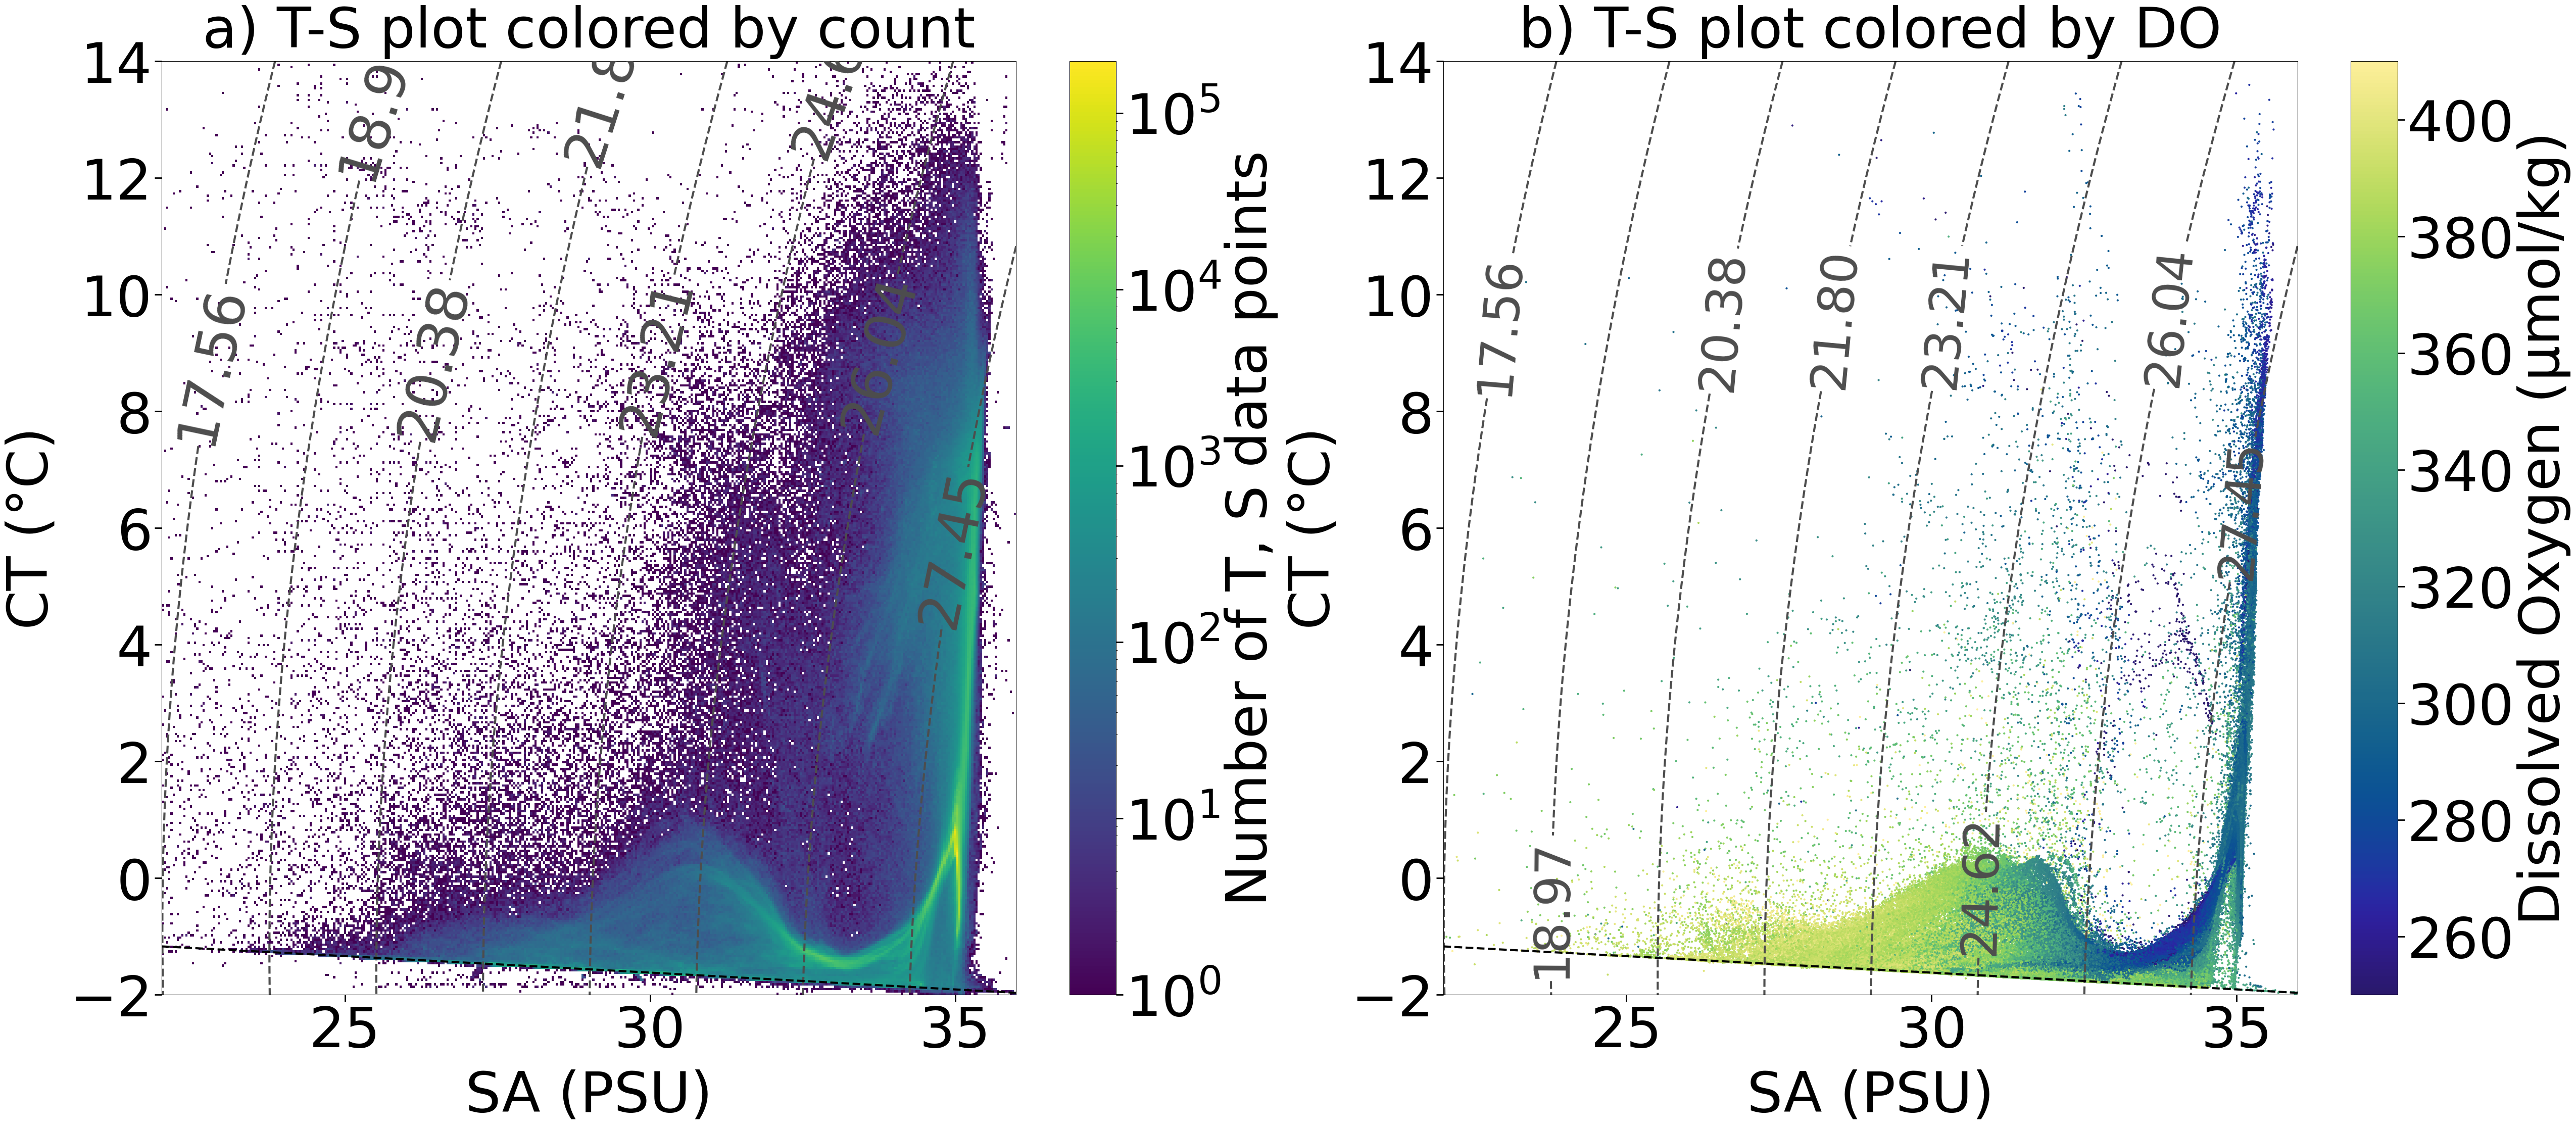

In [9]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import gsw
import cmocean.cm as cmo

def create_TS_plot(data):
    
    fig, ax = plt.subplots(1, 2, figsize=(60, 24))  # Bigger figure size

    # Bivariate histogram

    # Bivariate histogram
    hist = ax[0].hist2d(
        data['absolute_salinity'], 
        data['conservative_temp'], 
        bins=(np.linspace(22, 36, 400), np.linspace(-2, 14, 400)), 
        cmap='viridis', 
        norm=LogNorm()
    )

    # Sigma0 density contours
    SA, CT = np.meshgrid(np.linspace(22, 36, 400), np.linspace(-2, 14, 400))
    sigma0 = gsw.sigma0(SA, CT)
    levels = np.linspace(np.min(sigma0), np.max(sigma0), 10)
    contour = ax[0].contour(
        SA, CT, sigma0, levels=levels, 
        linestyles='--', colors='#4d4d4d', linewidths=3
    )
    ax[0].clabel(contour, inline=True, fontsize=80)
    
    # Freezing line
    CT_freezing = gsw.CT_freezing(np.linspace(22, 36, 400), 0, 0)
    ax[0].plot(
        np.linspace(22, 36, 400), CT_freezing, 
        linestyle='--', color='black', linewidth=3, label="Freezing Line"
    )

    # Labels and axis limits
    ax[0].set_xlabel('SA (PSU)', fontsize=80, labelpad=15)
    ax[0].set_ylabel('CT (\u00b0C)', fontsize=80, labelpad=15)
    ax[0].set_xlim([22, 36])
    ax[0].set_ylim([-2, 14])
    ax[0].tick_params(axis='both', which='major', labelsize=80, width=2, length=10)

    # Add title
    ax[0].set_title('a) T-S plot colored by count', fontsize=80, pad=20)

    # Colorbar
    cbar = plt.colorbar(hist[3], ax=ax[0])
    cbar.set_label('Number of T, S data points', fontsize=80)
    cbar.ax.tick_params(labelsize=80, width=2, length=10)

    # Scatter plot

    sc = ax[1].scatter(data['absolute_salinity'], data['conservative_temp'], c=data['oxygen'], s=4,cmap=cmo.haline, vmin=250, vmax=410)
    cbar = plt.colorbar(sc)
    # Add colorbar
    cbar.set_label('Dissolved Oxygen (\u00b5mol/kg)', fontsize=80)
    cbar.ax.tick_params(labelsize=80, width=2, length=10)

    # Sigma0 density contours
    SA, CT = np.meshgrid(np.linspace(22, 36, 400), np.linspace(-2, 14, 400))
    sigma0 = gsw.sigma0(SA, CT)
    levels = np.linspace(np.min(sigma0), np.max(sigma0), 10)
    contour = ax[1].contour(
        SA, CT, sigma0, levels=levels, 
        linestyles='--', colors='#4d4d4d', linewidths=3
    )
    ax[1].clabel(contour, inline=True, fontsize=70)

    # Freezing line
    CT_freezing = gsw.CT_freezing(np.linspace(22, 36, 400), 0, 0)
    ax[1].plot(
        np.linspace(22, 36, 400), CT_freezing, 
        linestyle='--', color='black', linewidth=3, label="Freezing Line"
    )

    # Labels and axis limits
    ax[1].set_xlabel('SA (PSU)', fontsize=80, labelpad=15)
    ax[1].set_ylabel('CT (\u00b0C)', fontsize=80, labelpad=15)
    ax[1].set_xlim([22, 36])
    ax[1].set_ylim([-2, 14])
    ax[1].tick_params(axis='both', which='major', labelsize=80, width=2, length=10)

    # Add title
    ax[1].set_title('b) T-S plot colored by DO', fontsize=80, pad=20)
    
    # Colorbar
    #cbar = plt.colorbar(hist[3], ax=ax)
    #cbar.set_label('Number of T, S data points', fontsize=70)
    #cbar.ax.tick_params(labelsize=60, width=2, length=10)

    # Remove grid
    ax[1].grid(False)

    # Show plot
    plt.show()

create_TS_plot(arctic)

Filter dataset into the properties and formation locations of water masses based on literature criteria (see Table 2 in paper for full references)


In [16]:
# Calculate potential density (needed for filtering)
import gsw
arctic['sigma0'] = gsw.sigma0(arctic['absolute_salinity'], arctic['conservative_temp'])

# Arctic Surface Water (ASW) - cold, fresh extreme
# - shallower than 26.0 isopycnal (Tsbouchi et al., 2012)
# - T<0degC (Rudels et al., 2005; Aksenov et al., 2010)
ASW = arctic[(arctic['latitude']>70)&(arctic['sigma0']<26) & (arctic['conservative_temp']<=0)]
# Pacific Water (summer and winter) 
# - formed in the Chukchi Sea (IHO definition) (Timmermans et al., 2014)
# - T=31-33 PSU (Talley, 2011; Coachman et al., 1975)
PW = arctic[(arctic['longitude']>=-179.5)&(arctic['longitude']<=-156.333)&(arctic['latitude']<=71.333)&(arctic['latitude']>=66.56)]
# Norwegian Current Water (NCW) - warm, salty extreme
# - formed in the Nordic Seas, enters along Norwegian Coast, with T=7-9 degC and S~35.2 PSU (Talley, 2011)
# - For context: Tmax = 8degC (Tsboouchi et al., 2012)
NCW = arctic[(arctic['latitude']<=73)&(arctic['latitude']>=65)&(arctic['longitude']>=0)&(arctic['longitude']<=20)& (arctic['conservative_temp']>=7)]
# Atlantic Water (AW) 
# - deeper than 27.1 isopycnal and lighter than 30.28 isopycnal (Tsubouchi et al., 2012)
# - T>0 degC (Richards et al., 2022) - this study also used basin-wide hydrographic data
# - Other T definitions for context: T=-1.8 to 2.5 (MacKinnon et al., 2021), T=0.4-3 degC and S>34.9 (Talley, 2011) etc.
AW = arctic[(arctic['sigma0']>=27.1)&(arctic['sigma0']<=30.28)&(arctic['conservative_temp']>0)] 
# Brine-enriched Water (BW) - cold, salty extreme
# - T<-1.5 degC (Skogeth et al., 2005))
BW = arctic[arctic['conservative_temp']<-1.5]


Plot T-S diagrams for each filtered water mass dataset, with SWT points overlaid (chosen as extremes in T-S space and literature informed)


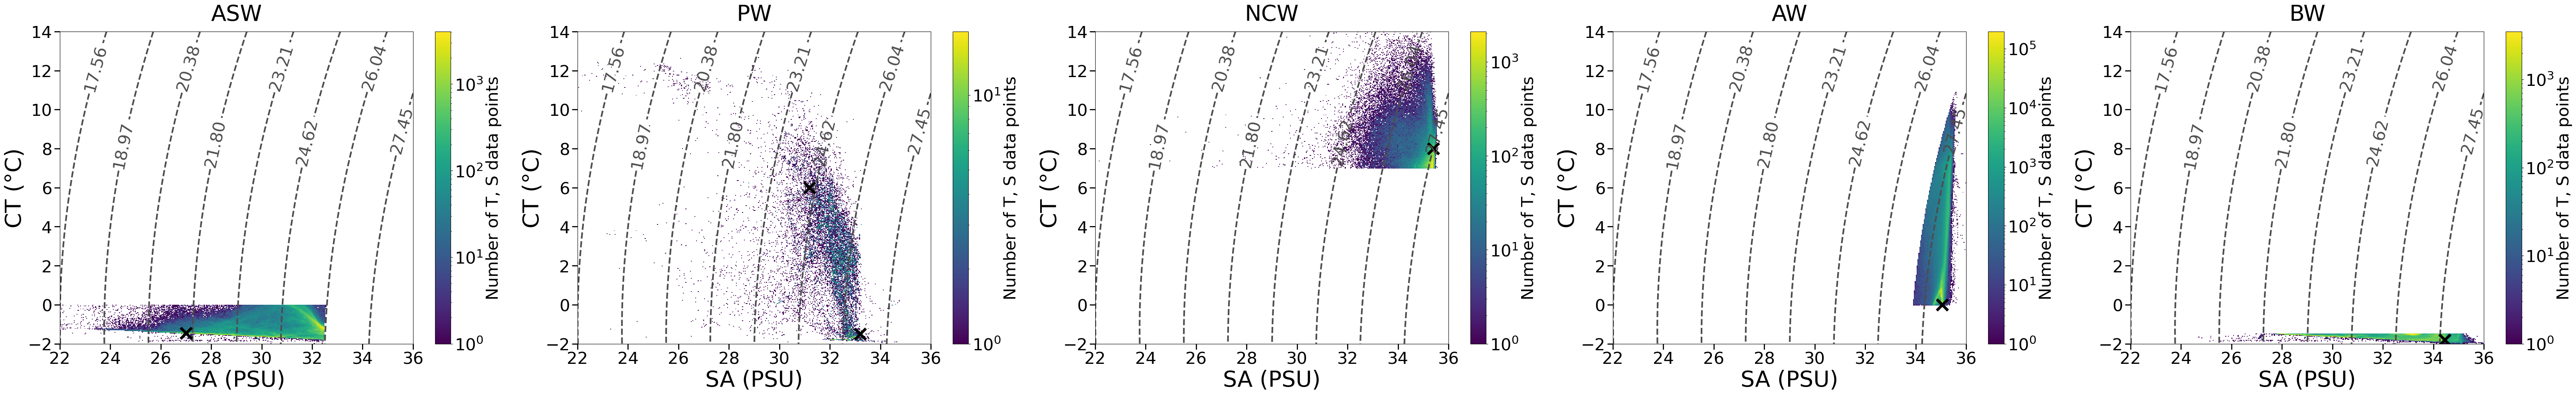

In [ ]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import gsw

def plot_T_S_count(
    ASW,
    PW,
    NCW,
    AW,
    BW
):
    fig, axes = plt.subplots(1, 5, figsize=(65, 10))  # 5 subplots in a row

    # 1st plot
    hist1 = axes[0].hist2d(ASW['absolute_salinity'], ASW['conservative_temp'],
                        bins=(np.linspace(22, 36, 400), np.linspace(-2, 14, 400)),
                        cmap='viridis', norm=LogNorm())
    SA, CT = np.meshgrid(np.linspace(22, 36, 400), np.linspace(-2, 14, 400))
    sigma0 = gsw.sigma0(SA, CT)
    contour1 = axes[0].contour(SA, CT, sigma0, levels=np.linspace(np.min(sigma0), np.max(sigma0), 10),
                            linestyles='--', colors='#4d4d4d', linewidths=3)
    axes[0].clabel(contour1, inline=True, fontsize=30)
    axes[0].set_xlabel('SA (PSU)', fontsize=40)
    axes[0].set_ylabel('CT (°C)', fontsize=40)
    axes[0].set_xlim([22, 36])
    axes[0].set_ylim([-2, 14])
    axes[0].tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    axes[0].set_title('ASW', fontsize=40, pad=20)
    cbar1 = plt.colorbar(hist1[3], ax=axes[0])
    cbar1.set_label('Number of T, S data points', fontsize=30)
    cbar1.ax.tick_params(labelsize=30)
    #Add SWT point at -1.45, 27.00
    axes[0].plot(27.00, -1.45, marker='x', color='black', markersize=20, markeredgewidth=5, label='Arctic Surface Water')

    # 2nd plot
    hist2 = axes[1].hist2d(PW['absolute_salinity'], PW['conservative_temp'],
                        bins=(np.linspace(22, 36, 400), np.linspace(-2, 14, 400)),
                        cmap='viridis', norm=LogNorm())
    contour2 = axes[1].contour(SA, CT, sigma0, levels=np.linspace(np.min(sigma0), np.max(sigma0), 10),
                            linestyles='--', colors='#4d4d4d', linewidths=3)
    axes[1].clabel(contour2, inline=True, fontsize=30)
    axes[1].set_xlabel('SA (PSU)', fontsize=40)
    axes[1].set_ylabel('CT (°C)', fontsize=40)
    axes[1].set_xlim([22, 36])
    axes[1].set_ylim([-2, 14])
    axes[1].tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    axes[1].set_title('PW', fontsize=40, pad=20)
    cbar2 = plt.colorbar(hist2[3], ax=axes[1])
    cbar2.set_label('Number of T, S data points', fontsize=30)
    cbar2.ax.tick_params(labelsize=30)
    # Add SWT point at 6, 31.2 and -1.5, 33.2
    axes[1].plot(31.2, 6, marker='x', color='black', markersize=20, markeredgewidth=5, label='summer Pacific Water')
    axes[1].plot(33.2, -1.5, marker='x', color='black', markersize=20, markeredgewidth=5, label='winter Pacific Water')


    # 3rd plot
    hist3 = axes[2].hist2d(NCW['absolute_salinity'], NCW['conservative_temp'],
                        bins=(np.linspace(22, 36, 400), np.linspace(-2, 14, 400)),
                        cmap='viridis', norm=LogNorm())
    contour3 = axes[2].contour(SA, CT, sigma0, levels=np.linspace(np.min(sigma0), np.max(sigma0), 10),
                            linestyles='--', colors='#4d4d4d', linewidths=3)
    axes[2].clabel(contour3, inline=True, fontsize=30)
    axes[2].set_xlabel('SA (PSU)', fontsize=40)
    axes[2].set_ylabel('CT (°C)', fontsize=40)
    axes[2].set_xlim([22, 36])
    axes[2].set_ylim([-2, 14])
    axes[2].tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    axes[2].set_title('NCW', fontsize=40, pad=20)
    cbar3 = plt.colorbar(hist3[3], ax=axes[2])
    cbar3.set_label('Number of T, S data points', fontsize=30)
    cbar3.ax.tick_params(labelsize=30)
    # Add SWT point at 8, 35.4
    axes[2].plot(35.4, 8, marker='x', color='black', markersize=20, markeredgewidth=5, label='Norwegian Current Water')

    # 4th plot
    hist4 = axes[3].hist2d(AW['absolute_salinity'], AW['conservative_temp'],
                        bins=(np.linspace(22, 36, 400), np.linspace(-2, 14, 400)),
                        cmap='viridis', norm=LogNorm())
    contour4 = axes[3].contour(SA, CT, sigma0, levels=np.linspace(np.min(sigma0), np.max(sigma0), 10),
                            linestyles='--', colors='#4d4d4d', linewidths=3)
    axes[3].clabel(contour4, inline=True, fontsize=30)
    axes[3].set_xlabel('SA (PSU)', fontsize=40)
    axes[3].set_ylabel('CT (°C)', fontsize=40)
    axes[3].set_xlim([22, 36])
    axes[3].set_ylim([-2, 14])
    axes[3].tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    axes[3].set_title('AW', fontsize=40, pad=20)
    cbar4 = plt.colorbar(hist4[3], ax=axes[3])
    cbar4.set_label('Number of T, S data points', fontsize=30)
    cbar4.ax.tick_params(labelsize=30)
    # Add SWT point at 0, 35.05
    axes[3].plot(35.05, 0, marker='x', color='black', markersize=20, markeredgewidth=5, label='Atlantic Water')


    # 5th plot
    hist5 = axes[4].hist2d(BW['absolute_salinity'], BW['conservative_temp'],
                        bins=(np.linspace(22, 36, 400), np.linspace(-2, 14, 400)),
                        cmap='viridis', norm=LogNorm())
    contour5 = axes[4].contour(SA, CT, sigma0, levels=np.linspace(np.min(sigma0), np.max(sigma0), 10),
                            linestyles='--', colors='#4d4d4d', linewidths=3)
    axes[4].clabel(contour5, inline=True, fontsize=30)
    axes[4].set_xlabel('SA (PSU)', fontsize=40)
    axes[4].set_ylabel('CT (°C)', fontsize=40)
    axes[4].set_xlim([22, 36])
    axes[4].set_ylim([-2, 14])
    axes[4].tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    axes[4].set_title('BW', fontsize=40, pad=20)
    cbar5 = plt.colorbar(hist5[3], ax=axes[4])
    cbar5.set_label('Number of T, S data points', fontsize=30)
    cbar5.ax.tick_params(labelsize=30)
    # Add SWT point at -1.8, 34.45
    axes[4].plot(34.45, -1.8, marker='x', color='black', markersize=20, markeredgewidth=5, label='Brine-enriched Water')

    plt.tight_layout()
    plt.show()

plot_T_S_count(ASW, PW, NCW, AW, BW)

Plot T-S diagrams (colored by oxygen) for each filtered water mass dataset, with SWT points overlaid (chosen as extremes in T-S space and literature informed)


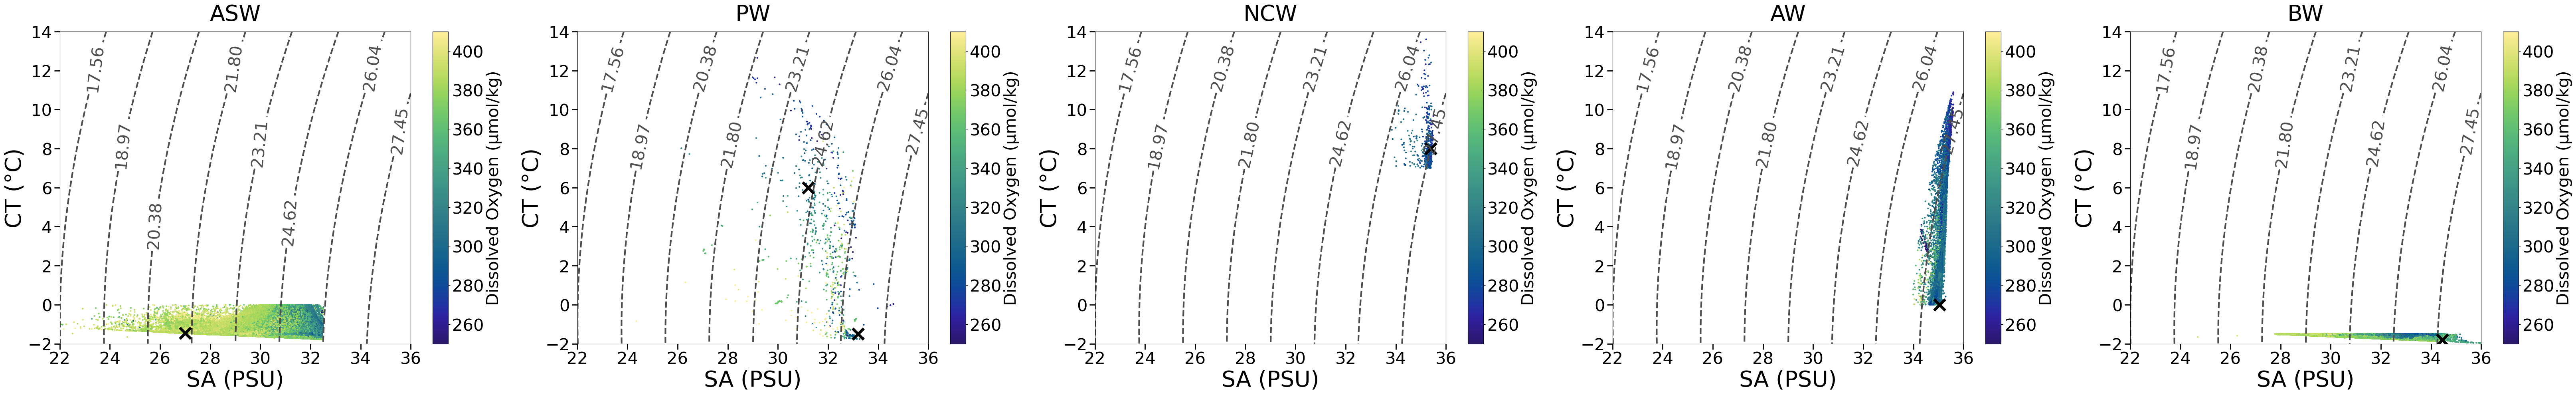

In [ ]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import gsw
import cmocean as cmo

def plot_T_S_DO(
    ASW,
    PW,
    NCW,
    AW,
    BW
):

    fig, axes = plt.subplots(1, 5, figsize=(65, 10))  # 5 subplots in a row

    # 1st plot
    sc = axes[0].scatter(ASW['absolute_salinity'], ASW['conservative_temp'], c=ASW['oxygen'], s=4,cmap=cmo.cm.haline, vmin=250, vmax=410)
    # Add colorbar
    cbar.set_label('Dissolved Oxygen (\u00b5mol/kg)', fontsize=30)
    cbar.ax.tick_params(labelsize=80, width=2, length=10)
    SA, CT = np.meshgrid(np.linspace(22, 36, 400), np.linspace(-2, 14, 400))
    sigma0 = gsw.sigma0(SA, CT)
    contour1 = axes[0].contour(SA, CT, sigma0, levels=np.linspace(np.min(sigma0), np.max(sigma0), 10),
                            linestyles='--', colors='#4d4d4d', linewidths=3)
    axes[0].clabel(contour1, inline=True, fontsize=30)
    axes[0].set_xlabel('SA (PSU)', fontsize=40)
    axes[0].set_ylabel('CT (°C)', fontsize=40)
    axes[0].set_xlim([22, 36])
    axes[0].set_ylim([-2, 14])
    axes[0].tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    axes[0].set_title('ASW', fontsize=40, pad=20)
    cbar1 = plt.colorbar(sc, ax=axes[0])
    cbar1.set_label('Dissolved Oxygen (\u00b5mol/kg)', fontsize=30)
    cbar1.ax.tick_params(labelsize=30)
    #Add SWT point at -1.45, 27.00
    axes[0].plot(27.00, -1.45, marker='x', color='black', markersize=20, markeredgewidth=5, label='Arctic Surface Water')

    # 2nd plot
    sc = axes[1].scatter(PW['absolute_salinity'], PW['conservative_temp'], c=PW['oxygen'], s=4,cmap=cmo.cm.haline, vmin=250, vmax=410)
    contour2 = axes[1].contour(SA, CT, sigma0, levels=np.linspace(np.min(sigma0), np.max(sigma0), 10),
                            linestyles='--', colors='#4d4d4d', linewidths=3)
    axes[1].clabel(contour2, inline=True, fontsize=30)
    axes[1].set_xlabel('SA (PSU)', fontsize=40)
    axes[1].set_ylabel('CT (°C)', fontsize=40)
    axes[1].set_xlim([22, 36])
    axes[1].set_ylim([-2, 14])
    axes[1].tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    axes[1].set_title('PW', fontsize=40, pad=20)
    cbar2 = plt.colorbar(sc, ax=axes[1])
    cbar2.set_label('Dissolved Oxygen (\u00b5mol/kg)', fontsize=30)
    cbar2.ax.tick_params(labelsize=30)
    # Add SWT point at 6, 31.2 and -1.5, 33.2
    axes[1].plot(31.2, 6, marker='x', color='black', markersize=20, markeredgewidth=5, label='summer Pacific Water')
    axes[1].plot(33.2, -1.5, marker='x', color='black', markersize=20, markeredgewidth=5, label='winter Pacific Water')


    # 3rd plot
    sc = axes[2].scatter(NCW['absolute_salinity'], NCW['conservative_temp'], c=NCW['oxygen'], s=4,cmap=cmo.cm.haline, vmin=250, vmax=410)

    contour3 = axes[2].contour(SA, CT, sigma0, levels=np.linspace(np.min(sigma0), np.max(sigma0), 10),
                            linestyles='--', colors='#4d4d4d', linewidths=3)
    axes[2].clabel(contour3, inline=True, fontsize=30)
    axes[2].set_xlabel('SA (PSU)', fontsize=40)
    axes[2].set_ylabel('CT (°C)', fontsize=40)
    axes[2].set_xlim([22, 36])
    axes[2].set_ylim([-2, 14])
    axes[2].tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    axes[2].set_title('NCW', fontsize=40, pad=20)
    cbar3 = plt.colorbar(sc, ax=axes[2])
    cbar3.set_label('Dissolved Oxygen (\u00b5mol/kg)', fontsize=30)
    cbar3.ax.tick_params(labelsize=30)
    # Add SWT point at 8, 35.4
    axes[2].plot(35.4, 8, marker='x', color='black', markersize=20, markeredgewidth=5, label='Norwegian Current Water')

    # 4th plot
    sc = axes[3].scatter(AW['absolute_salinity'], AW['conservative_temp'], c=AW['oxygen'], s=4,cmap=cmo.cm.haline, vmin=250, vmax=410)
    contour4 = axes[3].contour(SA, CT, sigma0, levels=np.linspace(np.min(sigma0), np.max(sigma0), 10),
                            linestyles='--', colors='#4d4d4d', linewidths=3)
    axes[3].clabel(contour4, inline=True, fontsize=30)
    axes[3].set_xlabel('SA (PSU)', fontsize=40)
    axes[3].set_ylabel('CT (°C)', fontsize=40)
    axes[3].set_xlim([22, 36])
    axes[3].set_ylim([-2, 14])
    axes[3].tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    axes[3].set_title('AW', fontsize=40, pad=20)
    cbar4 = plt.colorbar(sc, ax=axes[3])
    cbar4.set_label('Dissolved Oxygen (\u00b5mol/kg)', fontsize=30)
    cbar4.ax.tick_params(labelsize=30)
    # Add SWT point at 0, 35.05
    axes[3].plot(35.05, 0, marker='x', color='black', markersize=20, markeredgewidth=5, label='Atlantic Water')


    # 5th plot
    sc = axes[4].scatter(BW['absolute_salinity'], BW['conservative_temp'], c=BW['oxygen'], s=4,cmap=cmo.cm.haline, vmin=250, vmax=410)
    contour5 = axes[4].contour(SA, CT, sigma0, levels=np.linspace(np.min(sigma0), np.max(sigma0), 10),
                            linestyles='--', colors='#4d4d4d', linewidths=3)
    axes[4].clabel(contour5, inline=True, fontsize=30)
    axes[4].set_xlabel('SA (PSU)', fontsize=40)
    axes[4].set_ylabel('CT (°C)', fontsize=40)
    axes[4].set_xlim([22, 36])
    axes[4].set_ylim([-2, 14])
    axes[4].tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    axes[4].set_title('BW', fontsize=40, pad=20)
    cbar5 = plt.colorbar(sc, ax=axes[4])
    cbar5.set_label('Dissolved Oxygen (\u00b5mol/kg)', fontsize=30)
    cbar5.ax.tick_params(labelsize=30)
    # Add SWT point at -1.8, 34.45
    axes[4].plot(34.45, -1.8, marker='x', color='black', markersize=20, markeredgewidth=5, label='Brine-enriched Water')

    plt.tight_layout()
    plt.show()

plot_T_S_DO(ASW, PW, NCW, AW, BW)

**SWTs defined for different time periods**

In [21]:
# Extract summer (JAS) and winter (JFM) months
import datetime

ASW_summer = ASW[ASW['datetime'].dt.month.isin([7, 8, 9])]
ASW_winter = ASW[ASW['datetime'].dt.month.isin([1, 2, 3])]
PW_summer = PW[PW['datetime'].dt.month.isin([7, 8, 9])]
PW_winter = PW[PW['datetime'].dt.month.isin([1, 2, 3])]
NCW_summer = NCW[NCW['datetime'].dt.month.isin([7, 8, 9])]
NCW_winter = NCW[NCW['datetime'].dt.month.isin([1, 2, 3])]
AW_summer = AW[AW['datetime'].dt.month.isin([7, 8, 9])]
AW_winter = AW[AW['datetime'].dt.month.isin([1, 2, 3])]
BW_summer = BW[BW['datetime'].dt.month.isin([7, 8, 9])]
BW_winter = BW[BW['datetime'].dt.month.isin([1, 2, 3])]


Winter

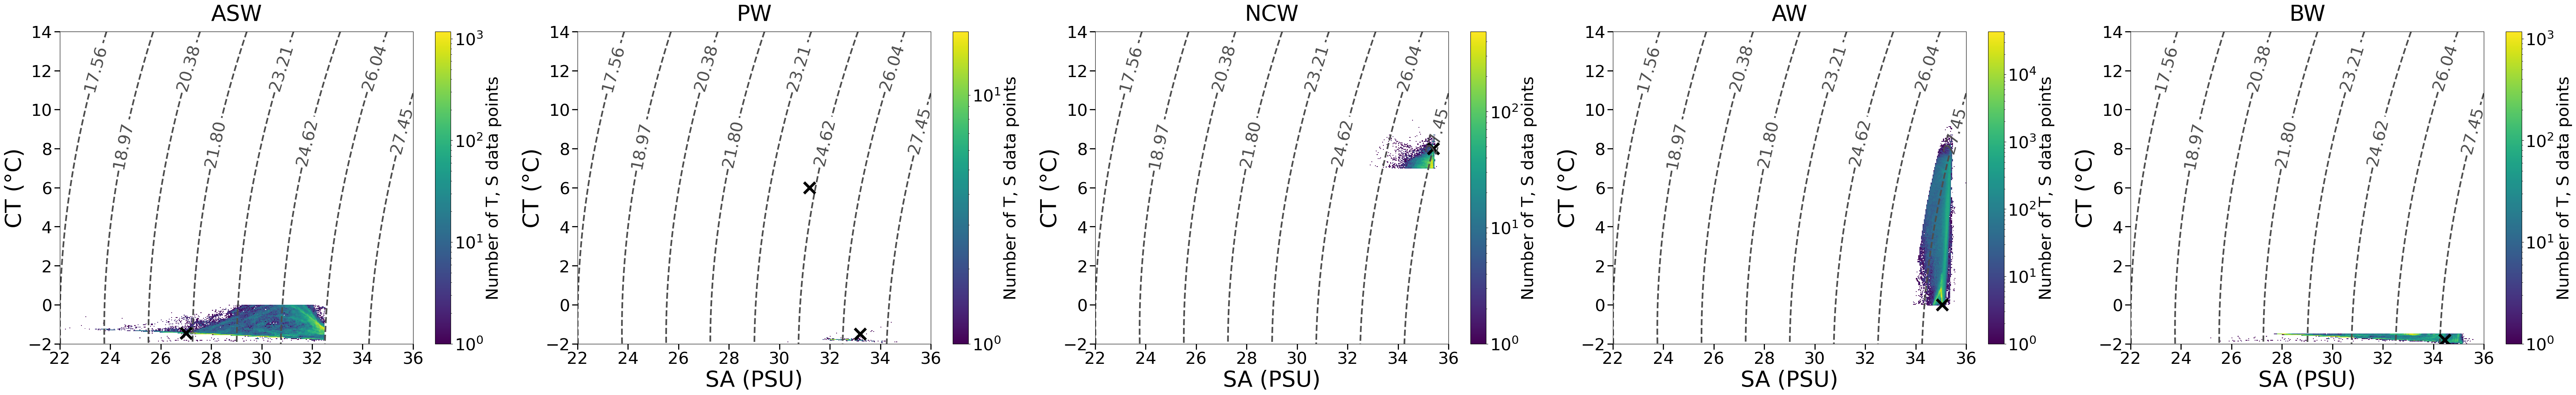

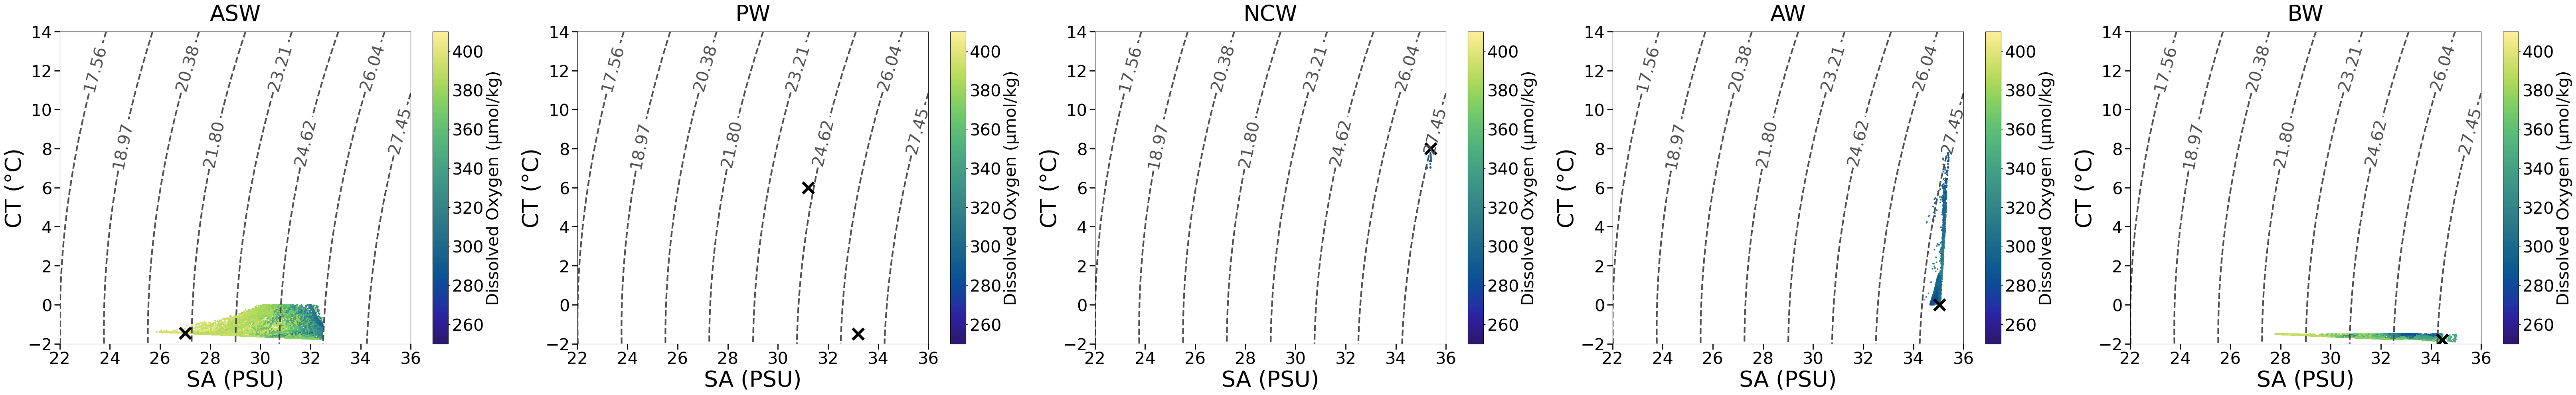

In [19]:
# Plot winter T-S diagrams
plot_T_S_count(ASW_winter, PW_winter, NCW_winter, AW_winter, BW_winter)
plot_T_S_DO(ASW_winter, PW_winter, NCW_winter, AW_winter, BW_winter)

Summer

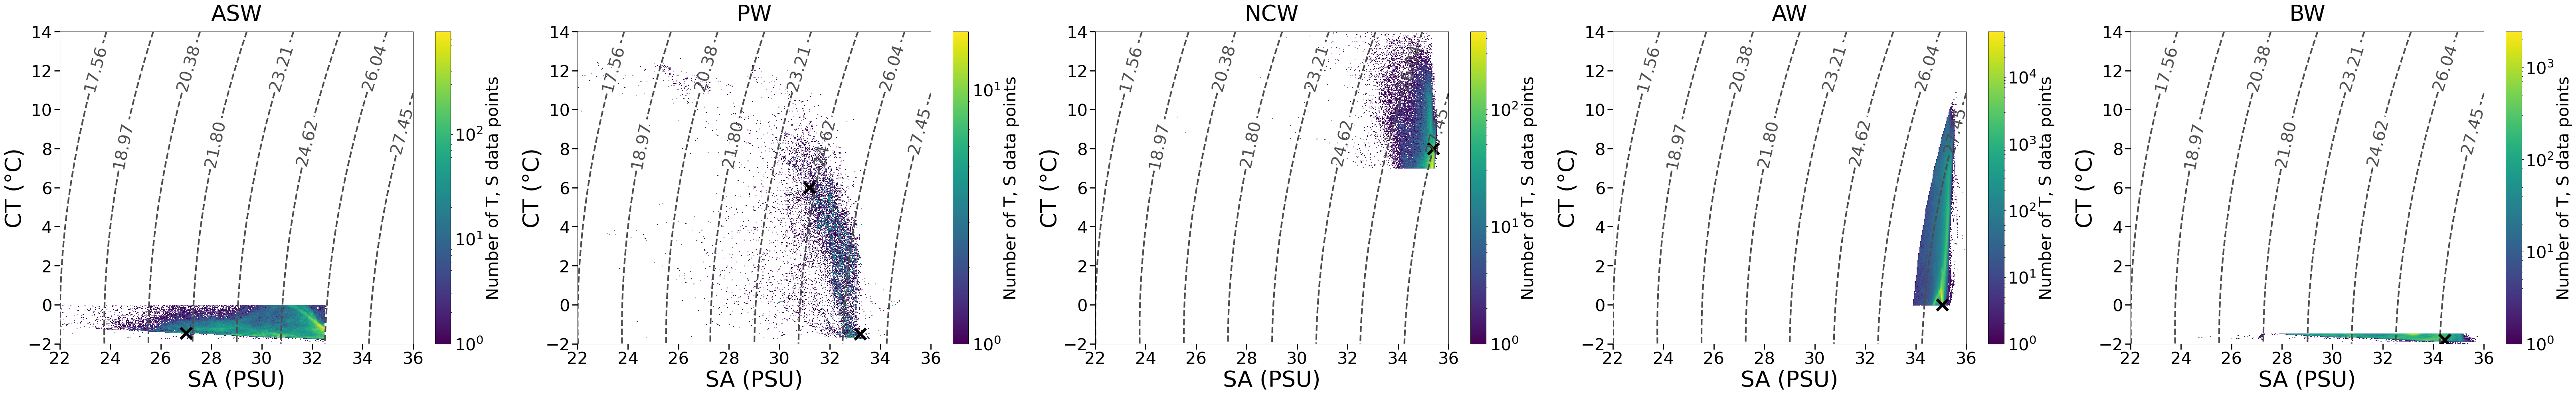

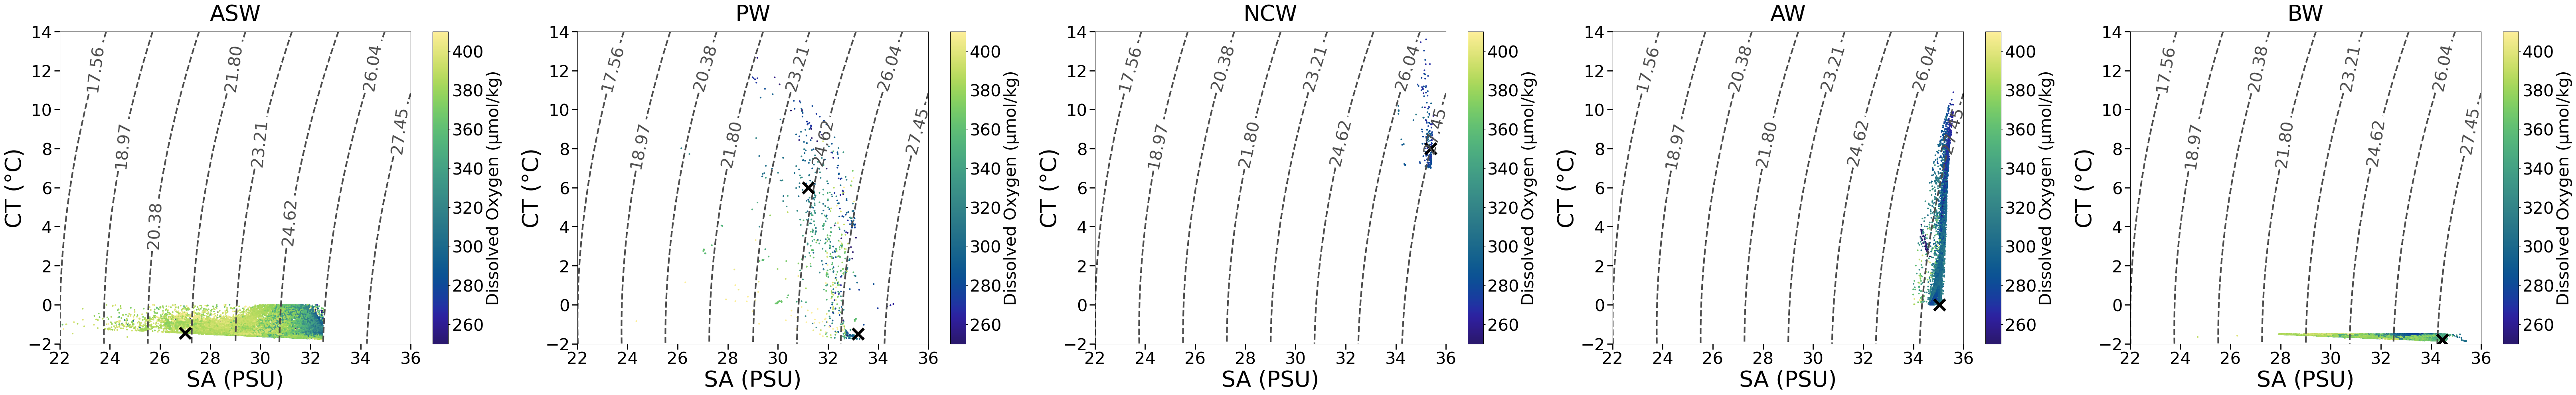

In [20]:
# Plot summer T-S diagrams
plot_T_S_count(ASW_summer, PW_summer, NCW_summer, AW_summer, BW_summer)
plot_T_S_DO(ASW_summer, PW_summer, NCW_summer, AW_summer, BW_summer)

Seasonal modification of end members:
- ASW warms and freshens in summer is T=-1.35, S=25.5, DO=367.25
- NCW warms and freshens (slightly) summer is T=12, S=35.3, DO=275.56
- sPW is removed in winter

The SWTs in our analysis need to account for winter and summer, so winter versions of SWTs are chosen, but we keep sPW because needs to be represented.

**SWTs for literature range**